In [88]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import figure



In [89]:
Raw = pd.read_csv(r"D:\archive.zip")

In [90]:
print(Raw.head(5))

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [91]:
print(Raw.shape)



(8807, 12)


In [92]:
print(Raw.info)


<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [93]:
print("miassing valuse: \n",Raw.isnull().sum())

miassing valuse: 
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [94]:
print("Duplicates: \n",Raw.duplicated().sum())

Duplicates: 
 0


In [95]:
Raw = Raw.dropna(subset=['duration'])
print(Raw.shape)


(8804, 12)


In [96]:
Raw["rating"] = Raw["rating"].fillna(Raw["rating"].mode()[0])

In [97]:
print(Raw["rating"].isnull().sum())

0


In [98]:
Raw = Raw.dropna(subset = ["date_added"])


In [99]:
print(Raw["date_added"].isnull().sum())

0


In [100]:
Raw["director"] = Raw["director"].fillna("Unknown")
Raw["country"] = Raw["country"].fillna("Unknown")
Raw["cast"] = Raw["cast"].fillna("Unknown")

In [101]:
print(Raw["director"].isnull().sum())

0


In [102]:
print(Raw.dtypes)

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [103]:
print(type(Raw))

<class 'pandas.DataFrame'>


In [104]:
print(Raw.head(5))

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [105]:
print("missing valuse: \n",Raw.isnull().sum())

missing valuse: 
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [106]:
print(Raw["date_added"].head())

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: str


In [107]:
Raw["date_added"] = pd.to_datetime(
    Raw["date_added"],
    errors="coerce"
)

In [108]:
Raw["date_added"] = pd.to_datetime(Raw["date_added"])

In [109]:
print(Raw["date_added"].head())

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]


In [110]:
Raw["date_added"] = pd.to_datetime(Raw["date_added"])

In [111]:
Raw["date_added"] = pd.to_datetime(Raw["date_added"],errors="coerce")

In [112]:
print(Raw["date_added"].isna().sum())

88


In [113]:
converted = pd.to_datetime(Raw["date_added"],errors="coerce")
print(Raw.loc[converted.isna(), "date_added"])

6079   NaT
6177   NaT
6213   NaT
6279   NaT
6304   NaT
        ..
8539   NaT
8557   NaT
8684   NaT
8712   NaT
8755   NaT
Name: date_added, Length: 88, dtype: datetime64[us]


In [114]:
print(Raw["date_added"].dtypes)

datetime64[us]


In [115]:
Raw["year_added"] = Raw["date_added"].dt.year
Raw["month_added"] = Raw["date_added"].dt.month_name()

In [116]:
print(Raw[["date_added","year_added","month_added"]].head())

  date_added  year_added month_added
0 2021-09-25      2021.0   September
1 2021-09-24      2021.0   September
2 2021-09-24      2021.0   September
3 2021-09-24      2021.0   September
4 2021-09-24      2021.0   September


### Movies vs TV shows

In [117]:
Raw["type"].value_counts()


type
Movie      6128
TV Show    2666
Name: count, dtype: int64

In [118]:
Raw["type"].value_counts(normalize=True)*100

type
Movie      69.683875
TV Show    30.316125
Name: proportion, dtype: float64

In [119]:
Raw["rating"].value_counts()

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [120]:
Raw["rating"].value_counts(normalize=True)*100

rating
TV-MA       36.490789
TV-14       24.528087
TV-PG        9.790766
R            9.085740
PG-13        5.571981
TV-Y7        3.786673
TV-Y         3.479645
PG           3.263589
TV-G         2.501706
NR           0.898340
G            0.466227
TV-Y7-FV     0.068228
NC-17        0.034114
UR           0.034114
Name: proportion, dtype: float64

In [121]:
Raw["country"].value_counts()
Raw["country"].value_counts(normalize=True)*100

country
United States                                    31.942233
India                                            11.052991
Unknown                                           9.438253
United Kingdom                                    4.753241
Japan                                             2.774619
                                                   ...    
Russia, Spain                                     0.011371
Croatia, Slovenia, Serbia, Montenegro             0.011371
Japan, Canada                                     0.011371
United States, France, South Korea, Indonesia     0.011371
United Arab Emirates, Jordan                      0.011371
Name: proportion, Length: 749, dtype: float64

In [122]:
Raw["release_year"].value_counts()

release_year
2018    1146
2017    1031
2019    1030
2020     953
2016     901
        ... 
1961       1
1959       1
1925       1
1966       1
1947       1
Name: count, Length: 74, dtype: int64

In [123]:
Raw["release_year"].value_counts().head(10)

release_year
2018    1146
2017    1031
2019    1030
2020     953
2016     901
2021     592
2015     557
2014     352
2013     287
2012     236
Name: count, dtype: int64

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

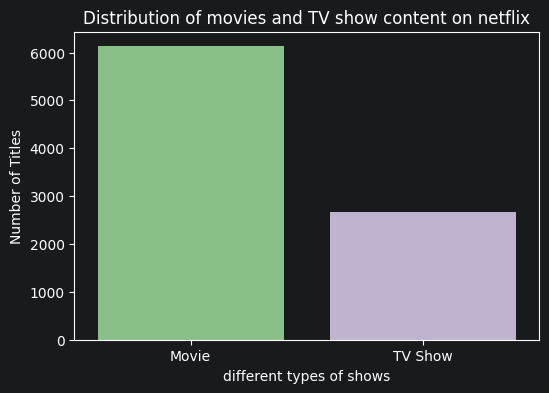

In [199]:
plt.figure(figsize=(6,4))
sns.countplot(data=Raw , x="type",hue = "type",palette="Accent")
plt.title("Distribution of Content Ratings on Netflix")
plt.title("Distribution of movies and TV show content on netflix")
plt.xlabel("different types of shows")
plt.ylabel("Number of Titles")

plt.show()



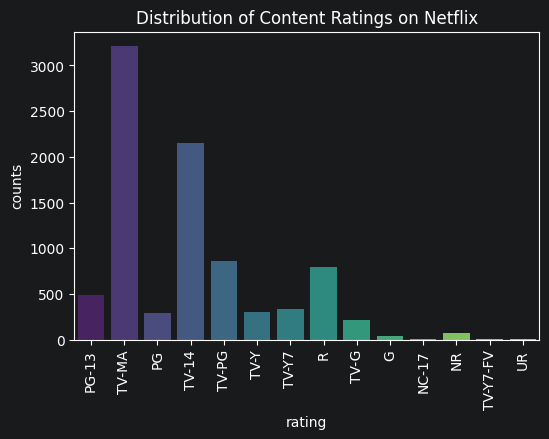

In [136]:
plt.figure(figsize=(6,4))
sns.countplot(data=Raw , x="rating",hue = "rating" ,palette="viridis")
plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("rating")
plt.xticks(rotation=90)
plt.ylabel("counts")
plt.show()

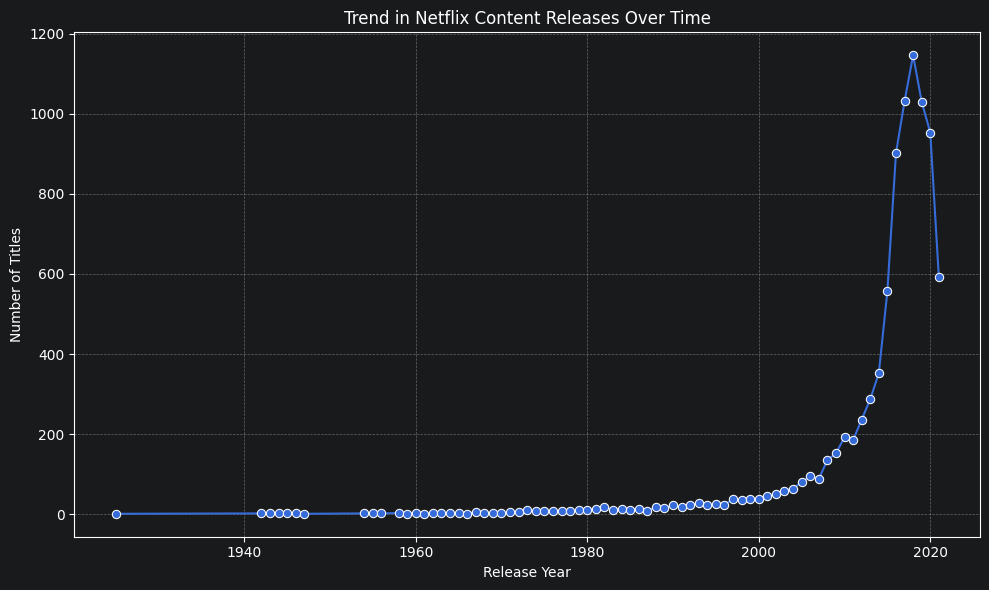

In [127]:
# Count the number of titles released each year
year_count = (
    Raw["release_year"]
    .value_counts()
    .sort_index()
    .reset_index(name="count")
)

# Rename the columns
year_count.columns = ["release_year", "count"]

# Plot the line chart
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=year_count,
    x="release_year",
    y="count",
    marker="o"
)

plt.title("Trend in Netflix Content Releases Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [128]:
print(Raw.head(5))

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Season   
3 2021-0

In [129]:
Raw["listed_in"].value_counts()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Comedies, Cult Movies, LGBTQ Movies                   1
Action & Adventure, Comedies, Horror Movies           1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Action & Adventure, Documentaries, Sports Movies      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 513, dtype: int64

In [178]:
genre = Raw["listed_in"].str.split(",").explode()

In [187]:
top_genre = genre.value_counts().head(10)

In [188]:
print(top_genre)

listed_in
 International Movies     2624
Dramas                    1600
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     773
 Independent Movies        736
 TV Dramas                 695
 Romantic Movies           613
Name: count, dtype: int64


In [173]:
import seaborn as sns

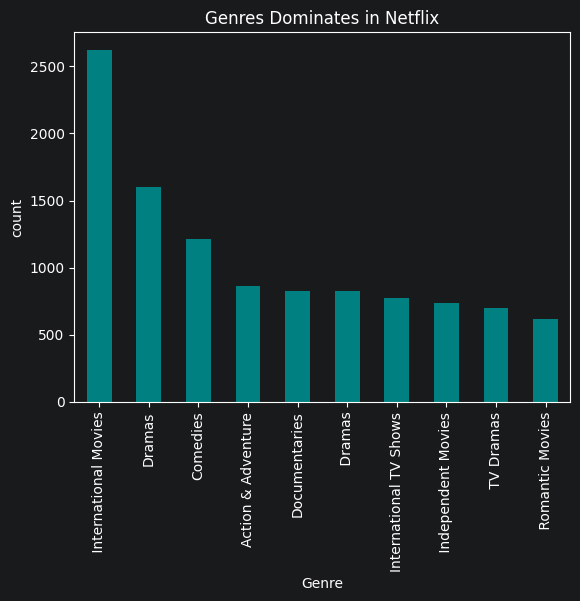

In [198]:

top_genre.plot(kind = "bar",color= "teal")
plt.title("Genres Dominates in Netflix")
plt.xlabel("Genre")
plt.ylabel("count")
plt.show()


## Movies VS Shows Over the years

In [ ]:
Raw.head(5)

In [ ]:
Raw["type"].value_counts()

### here we use groupedby()

In [ ]:
Raw["type"].value_counts(normalize=True)*100

In [ ]:
year_type = (
    Raw.groupby(["release_year" ,"type"])
       .size()
       .reset_index(name = "counts")
)

In [ ]:
print(year_type.head(5))

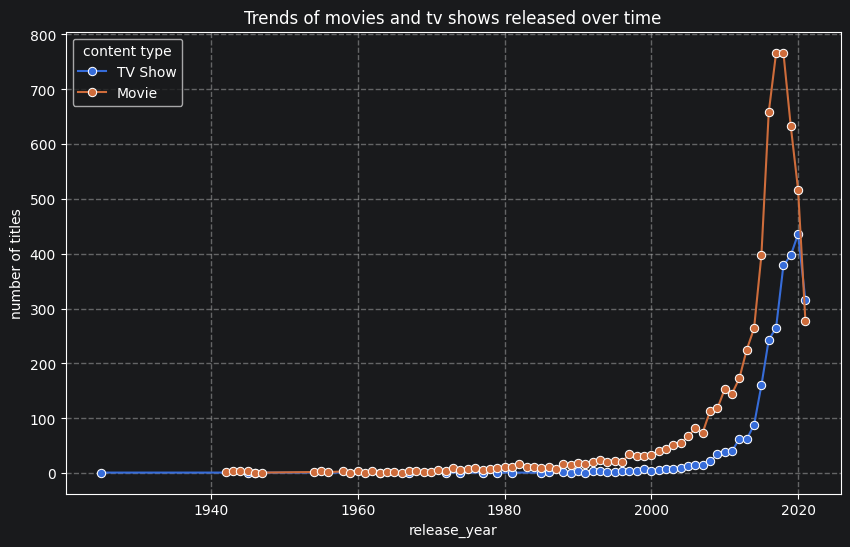

In [200]:
plt.figure(figsize=(10, 6))
sns.lineplot(x = "release_year", y = "counts", data = year_type, hue="type",marker="o")
plt.title("Trends of movies and tv shows released over time")
plt.xlabel("release_year")
plt.ylabel("number of titles")

plt.grid(True, linestyle="--", alpha=0.5,linewidth=1)
plt.legend(title="content type")

plt.show()

In [ ]:
Raw["month_added"].value_counts()

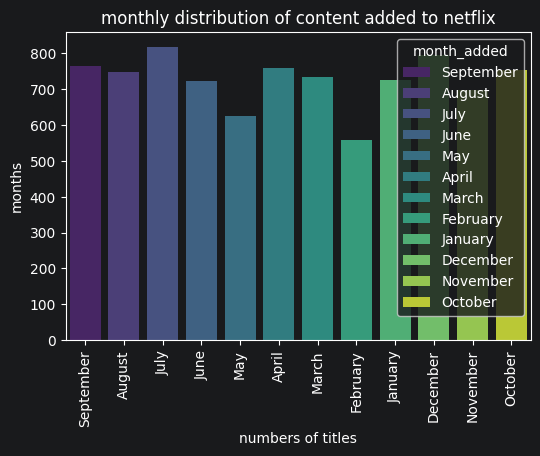

In [142]:
plt.figure(figsize=(6, 4))
sns.countplot(data=Raw ,x = "month_added",palette = "viridis",hue = "month_added",)
plt.title("monthly distribution of content added to netflix")
plt.xlabel("numbers of titles")
plt.xticks(rotation=90)
plt.ylabel("months")
plt.show()

In [ ]:
Raw["duration"].head(5)

In [ ]:
movies = Raw[Raw["type"] == "Movie"]


In [ ]:
print(movies)

In [ ]:
movies["duration"] = movies["duration"].str.extract(r"(\d+)").astype(int)

In [138]:
print(movies.shape)
print(movies["duration"].dtype)
print(movies["duration"].isna().sum())
print(movies["duration"].describe())

(6128, 14)
int64
0
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64


In [ ]:
print(Raw["type"].unique())

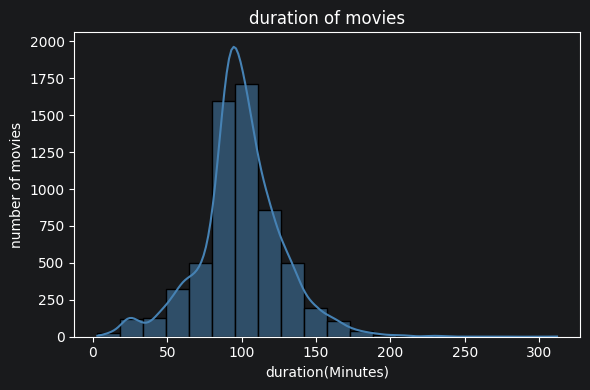

In [137]:
plt.figure(figsize=(6, 4))
sns.histplot(data=movies,
             x="duration",
             color="SteelBlue",
             bins = 20 ,
             kde  = True)
plt.title("duration of movies")
plt.xlabel("duration(Minutes)")
plt.ylabel("number of movies")

plt.tight_layout()
plt.show()


## Top ten Directors

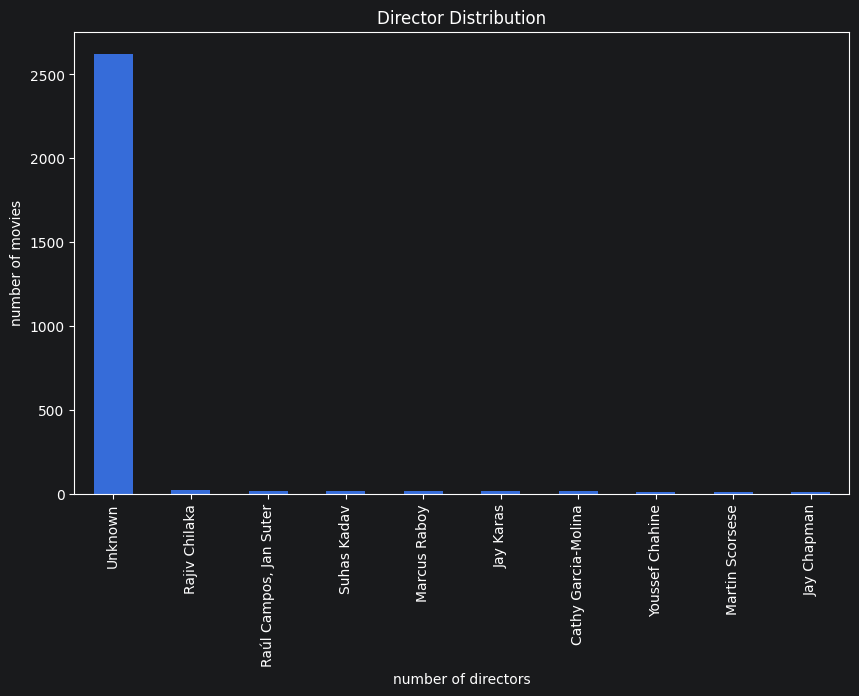

In [163]:
plt.figure(figsize=(10,6))
top_ten.plot(kind="bar")
plt.title("Director Distribution")
plt.xlabel("number of directors")
plt.ylabel("number of movies")

plt.show()

